In [1]:
import operator
from typing import Annotated, Sequence, TypedDict,Literal, List, Dict, Tuple, Union
import functools
import os

from langchain.agents import AgentExecutor, create_openai_functions_agent
from typing import Callable
from langchain_core.tools import tool, StructuredTool
from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
# from langchain_anthropic import ChatAnthropic
from langchain_openai import AzureChatOpenAI
# from langchain_deepseek import ChatDeepSeek

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode,create_react_agent
from pydantic import BaseModel, Field

from src.agent import create_agent
from src.tools import find_pseudopotential, submit_single_job,write_script,calculate_lc,generate_convergence_test,generate_eos_test,\
submit_and_monitor_job,find_job_list,read_energy_from_output,add_resource_suggestion, get_kspacing_ecutwfc, init_structure_data, write_LAMMPS_script,\
find_classical_potential
from src.prompt import dft_agent_prompt,hpc_agent_prompt,supervisor_prompt
from src.utils import load_config, save_graph_to_file,check_config

ImportError: cannot import name 'AgentExecutor' from 'langchain.agents' (/home/ziqiw/.conda/envs/agent-ursa/lib/python3.11/site-packages/langchain/agents/__init__.py)

In [4]:
config = load_config(os.path.join('/nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent/config', "default.yaml"))

llm = AzureChatOpenAI(model="gpt-4o", temperature=0.0, api_version="2024-08-01-preview", api_key=config["OpenAI_API_KEY"], azure_endpoint = config["OpenAI_BASE_URL"])

In [5]:
@tool
def add(a: int, b: int) -> int:
    """Add two integers.

    Args:
        a: First integer
        b: Second integer
    """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers.

    Args:
        a: First integer
        b: Second integer
    """
    return a * b

In [6]:
from typing import Callable

class DynamicToolRegistry:
    def __init__(self):
        self.tools = {}

    def add_tool(self, name: str, func: Callable, description: str = "No description provided"):
        """Add a tool dynamically."""
        self.tools[name] = func

    def remove_tool(self, name: str):
        """Remove a tool dynamically."""
        if name in self.tools:
            del self.tools[name]

    def get_tools(self):
        """Return all currently available tools."""
        return list(self.tools.values())

In [8]:
# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [7]:
tool_registry = DynamicToolRegistry()

In [10]:
tool_registry.add_tool("add", add)

In [13]:
tool_registry.tools

{'add': <function __main__.add(a: int, b: int) -> int>}

In [12]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    pass

In [14]:
import json 
from langchain_core.messages import ToolMessage

def tool_execution_node(state: AgentState) -> AgentState:
    """Executes the requested tool dynamically."""
    # Get the last AI message
    last_message = state["messages"][-1]
    print("executing tool last_message", last_message)

    # Extract tool calls
    tool_calls = last_message.additional_kwargs.get("tool_calls", [])
    available_tools = tool_registry.get_tools()

    print("tool_calls", tool_calls)

    tool_call = tool_calls[0].get("function")  # Assuming single tool call per message
    tool_name = tool_call["name"]
    tool_args = json.loads(tool_call["arguments"])

    # Fetch available tools
    available_tools = tool_registry.tools
    print("available tool", available_tools)  # Ensure this function exists

    if tool_name in available_tools:
        tool = available_tools[tool_name]
        print("tool_args", tool_args)

        # Ensure arguments are passed as keyword arguments
        result = tool(**tool_args)
        return {"messages" : ToolMessage(content=result, tool_call_id=tool_calls[0].get("id"))}
    else:
        return {"messages" : f"Tool '{tool_name}' not found."}

In [15]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

prompt = """You are a helpful assistant tasked with performing arithmetic on a set of inputs.  
**Instructions:**  
- Do not perform arithmetic actions directly without a tool.
- Determine if you have a tool to perform required arithmetic action. If no tool present respond with: 'Need to create [description of tool].' This will create a new tool to use
- Use existing tools or create new ones to complete the task."""

sys_msg = SystemMessage(content= prompt) 
def assistant(state: AgentState):
    # print("assistan",state["tool_all"])
    print("toolzaa 1: ",tool_registry.get_tools() )
    llm_with_tools = llm.bind_tools(tool_registry.get_tools(), parallel_tool_calls=False)
    output={"messages": [llm_with_tools.invoke(([sys_msg]) + state["messages"])]}
    return output

In [17]:
import ast
import tkinter as tk

In [ ]:
contrent1 = "You are an experienced Python programmer. Your task is to write a genric python function for given problem statement."
prompt1 =  f"""
    The function should:
    - Have type hints.
    - Include a proper docstring.
    - Doc example: Adds a and b.

                        Args:
                            a: first int
                            b: second int
    -Return the function code without explanations.
    """
sys_msg2 = SystemMessage(content= contrent1, prompt = prompt1)
def tool_creater(state: AgentState):
    try:
        
        output={"message": [llm.invoke(([sys_msg2]) + [state['messages'][-1]])]}
        real_output = large_text_input(initial_text=extract_code(output["message"][0].content))
        exec(real_output, globals())
        func_name = get_function_name_from_string(real_output)
        print(func_name)
        tool_registry.add_tool(func_name, globals().get(func_name))
        return
    except Exception as e:
        print(e)
        return 

In [ ]:
print("Python script running...", flush=True)

from executorlib import SlurmClusterExecutor
from pathlib import Path
from datetime import datetime
from ase import Atoms
from pymatgen.io.ase import AseAtomsAdaptor

from GNoME_DREAMS_OER_screening.vasp.pre_defined_vasp_sets import (
    TestRelaxSet
)
from GNoME_DREAMS_OER_screening.vasp.vasp_calculation import exlib_run_vasp


run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

# --- Dummy atoms object for testing ---
test_atoms = Atoms('H', positions=[[0, 0, 0]], cell=[6, 6, 6], pbc=True)
test_atoms.center()
test_structure = AseAtomsAdaptor.get_structure(test_atoms) # pymatgen Structure object

# --- Setup of VASP directories ---
vasp_calc_main_dir = Path("VASP_calculations/test_run_" + run_id)
calc_paths = [vasp_calc_main_dir / f"calc_{i}" for i in range(5)]

for path in calc_paths:
    vasp_set = TestRelaxSet(test_structure)
    vasp_set.write_input(output_dir = path) 

# --- Cache location (for executorlib) ---
cache_dir = (
    Path("/home/scratch3/")
    / 'matnis'
    / "executorlib"
    / "first_VASP_test"
    / run_id
)

slurm_template = Path("slurm_templates/test_template.sh").read_text()

# --- Submit job ---
print("--- Submitting job to Slurm cluster... ---", flush=True)
with SlurmClusterExecutor(cache_directory=cache_dir) as exe:
    futures = []

    for i, calc_path in enumerate(calc_paths):
        f = exe.submit(
            exlib_run_vasp,
            calc_path.resolve(),
            resource_dict={
                "submission_template": slurm_template,
            },
        )
        futures.append(f)
        print(f"Submitted job {i}, future: {f}", flush=True)
    print("--- All jobs submitted ---", flush=True)

    results = [f.result() for f in futures]
    print("Results:", results)

for result in results:
    print("VASP run result:", result['E'])

In [ ]:
# it requires a dir for the vasp files (calculations):

# --- Setup of VASP directories ---
vasp_calc_main_dir = Path("VASP_calculations/test_run_" + run_id)

# and one for exlib to store inputs/outputs:
# --- Cache location (for executorlib) ---
cache_dir = (
    Path("/home/scratch3/")
    / 'matnis'
    / "executorlib"
    / "first_VASP_test"
    / run_id
)

In [1]:
import os
print(f"sys path: {os.sys.path}")

sys path: ['/home/ziqiw/.conda/envs/agent-ursa/lib/python311.zip', '/home/ziqiw/.conda/envs/agent-ursa/lib/python3.11', '/home/ziqiw/.conda/envs/agent-ursa/lib/python3.11/lib-dynload', '', '/home/ziqiw/.local/lib/python3.11/site-packages', '/home/ziqiw/.conda/envs/agent-ursa/lib/python3.11/site-packages']


In [2]:
import os
import sys
sys.path.insert(0, "/nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent")

import yaml
import getpass
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
# from langchain_anthropic import ChatAnthropic

from langgraph.prebuilt import create_react_agent
# from src.prompt import hpc_agent_prompt,dft_agent_prompt
# from src.graph import create_graph
# from src.planNexe2 import create_planning_graph as create_graph
# from src.planNexeHighPlan import create_planning_graph as create_graph

import time
from src.utils import load_config, save_graph_to_file,initialize_database
from src.myCANVAS import CANVAS
from src import var


In [1]:
import operator
from typing import Annotated, Sequence, TypedDict,Literal, List, Dict, Tuple, Union
import functools
import os

from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
)
from langchain_anthropic import ChatAnthropic
# from langchain_openai import AzureChatOpenAI
# from langchain_deepseek import ChatDeepSeek

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode,create_react_agent
from pydantic import BaseModel, Field

from src.tools import *
from src.prompt import dft_agent_prompt,hpc_agent_prompt,supervisor_prompt, oer_agent_prompt
from src import var

# members = ["DFT_Agent", "HPC_Agent", "OER_Agent"]
members = ["DFT_Agent"]

instructions = [dft_agent_prompt, hpc_agent_prompt, oer_agent_prompt]
OPTIONS = members

# This defines the object that is passed between each node
# in the graph. We will create different nodes for each agent and tool
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], operator.add]
#     next: str

class myStep(BaseModel):
    """Step in the plan."""

    step: str = Field(description="Step to perform.")
    agent: str = Field(
        description=f"Agent to perform the step. Should be one of {members}."
    )

class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[myStep] = Field(
        description=f"""
        Steps to follow in future. Each step is a tuple of (step, agent). agent can only be chosen from {members}.
        """
        # description="different steps to follow, should be in sorted order"
        # description="""different steps to follow (first element of the Tuple), and the agent in charge for each step (second element of the Tuple),
        # should be in sorted order by the order of execution"""
    )
    

class Response(BaseModel):
    """End everything and response to the user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Plan, Response] = Field(
        description="Action to perform. If you need to further use tools to get the answer, use Plan."
        "If you want to end the conversation, use Response."
        # "DO NOT use response unless absolutly necessary."
    )

class PlanExecute(TypedDict):
    input: str
    plan: List[myStep]
    past_steps: List[myStep]
    response: str
    next: str

teamCapability = ""


teamRestriction = ""


def print_stream(s):
    if "messages" not in s:
        print("#################")
        if var.my_SAVE_DIALOGUE:
            with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                f.write("#################\n")
        print(s)
        if var.my_SAVE_DIALOGUE:
            with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                f.write(repr(s))
                f.write("\n")
    else:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
            if var.my_SAVE_DIALOGUE:
                with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                    f.write(repr(message))
                    f.write("\n")
        else:
            if hasattr(message, 'usage_metadata'):
                var.TOKEN_USAGE.append(message.usage_metadata)
                print(f"input_tokens: {message.usage_metadata['input_tokens']}, output_tokens: {message.usage_metadata['output_tokens']}")
                if var.my_SAVE_DIALOGUE:
                    with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                        f.write(f"input_tokens: {message.usage_metadata['input_tokens']}, output_tokens: {message.usage_metadata['output_tokens']}\n")
            message.pretty_print()
            if var.my_SAVE_DIALOGUE:
                with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                    f.write(message.pretty_repr())
                    f.write("\n")
    print()
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write("\n")

# def agent_node(state, agent, name):
#     print(f"Agent {name} is processing!!!!!")
#     for s in agent.stream(state, {"recursion_limit": 1000}):
#         print_stream(s)
#     return {"messages": [HumanMessage(content=s["messages"][-1].content, name=name)]}

def supervisor_chain_node(state, chain, name):
    
    # read "status.txt" in the working directory
    with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
        status = f.read()
    while status == "stop":
        print(f"Calculation pause, supervisor is waiting. cwd: {var.my_WORKING_DIRECTORY}")
        # wait for 5 second
        time.sleep(5)
        with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
            status = f.read()
    
    print(f"supervisor is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"supervisor is processing!!!!!\n")

    print(state)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(str(state))
            f.write("\n")

    output = chain.invoke(state)

    if isinstance(output.action, Response):
        return {"response": output.action.response, "next": "FINISH"}
    # elif isinstance(output.action, Response):
    #     return {"response": "Plan is not finished! Do not use response!", "next": "Supervisor"}
    else:
        return {"plan": output.action.steps, "next": output.action.steps[0].agent}
    
    

def worker_agent_node(state, agent, name, past_steps_list):
    # read "status.txt" in the working directory
    with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
        status = f.read()
    while status == "stop":
        print(f"Calculation pause, {name} Agent is waiting. cwd: {var.my_WORKING_DIRECTORY}")
        # wait for 5 second
        time.sleep(5)
        with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
            status = f.read()
    
    print(f"Agent {name} is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"Agent {name} is processing!!!!!\n")
        
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step.step}" for i, step in enumerate(plan))
    print(plan_str)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(plan_str)
            f.write("\n")
    task = plan[0]
#     task_formatted = f"""For the following plan:
# {plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    old_tasks_string = "\n".join(f"{i+1}. {step.agent}: {step.step}" for i, step in enumerate(past_steps_list))
    task_formatted = f"""
Here are what has been done so far:
{old_tasks_string}

Here is the overall objective:
{state["input"]}

Now, you are tasked with: {task}. Please only do this task! Do not do anything else!
"""
    
    print(task_formatted)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(task_formatted)
            f.write("\n")
    print(f"Agent {name} is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"Agent {name} is processing!!!!!\n")
    
    
    for agent_response in agent.stream(
        {"messages": [("user", task_formatted)]},  {"configurable": {"thread_id": "1"}, "recursion_limit": 1000}
    ):
        # set agent_response to be the value of the first key of the dictionary
        agent_response = next(iter(agent_response.values()))
        print_stream(agent_response)
    
    # agent_response = agent.invoke(
    #     {"messages": [("user", task_formatted)]},  {"configurable": {"thread_id": "1"}}
    # )
    
    # past_steps_list.append((task, agent_response["messages"][-1].content))
    past_steps_list.append(myStep(step=agent_response["messages"][-1].content, agent=name))
    
    print_stream(agent_response)
    
    return {
        "past_steps": past_steps_list,
    }
    
def recusive_agent_node(state, agent, name, past_steps_list):
    print(f"Agent {name} is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"Agent {name} is processing!!!!!\n")
    
def whos_next(state):
    return state["next"]
        
def create_planning_graph_hh(config: dict) -> StateGraph:
    # create a file named status.txt in the working directory
    WORKING_DIRECTORY = var.my_WORKING_DIRECTORY
    with open(f"{WORKING_DIRECTORY}/status.txt", "w") as f:
        f.write("run")
    
    # Define the model
    llm = ChatAnthropic(model="claude-sonnet-4-5-20250929", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    workerllm = ChatAnthropic(model="claude-sonnet-4-5-20250929", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    # workerllm = ChatAnthropic(model="claude-3-5-sonnet-20241022", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    # llm = AzureChatOpenAI(model="gpt-4o", api_version="2024-08-01-preview", api_key=config["OpenAI_API_KEY"], azure_endpoint = config["OpenAI_BASE_URL"])
    # workerllm = AzureChatOpenAI(model="gpt-4o", api_version="2024-08-01-preview", api_key=config["OpenAI_API_KEY"], azure_endpoint = config["OpenAI_BASE_URL"], model_kwargs={'parallel_tool_calls': False})
    # llm = ChatDeepSeek(model_name=config["DeepSeek_MDL"], api_key=config['DeepSeek_API_KEY'], api_base=config['DeepSeek_BASE_URL'], temperature=0.0)
    
    var.my_WORKING_DIRECTORY = var.my_WORKING_DIRECTORY
    
    if not eval(config["SAVE_DIALOGUE"]):
        var.my_SAVE_DIALOGUE = False
    
    supervisor_prompt = ChatPromptTemplate.from_template(
        f"""
<Role>
    You are a scientist supervisor tasked with managing a conversation for scientific computing between the following workers: {members}. You don't have to use all the members, nor all the capabilities of the members.

        """
    )
    
    
    # System Supervisor with tool bind and with_structured_output
    
    # supervisor_chain = supervisor_prompt | llm.bind_tools(supervisor_tools).with_structured_output(Act)
    # supervisor_agent = functools.partial(supervisor_chain_node, chain=supervisor_chain, name="Supervisor")
    
    
        
    
    # def supervisor_agent(state):
    #     print("Supervisor!!!!!!!!!")
    #     supervisor_chain = (
    #         prompt
    #         | llm.with_structured_output(routeResponse)
    #     )
    #     return supervisor_chain.invoke(state)
    
    ## Memory Saver
    memory = MemorySaver()

    PAST_STEPS = []
    myCANVAS = {}
    
    supervisor_tools = [
        inspect_my_canvas,
        read_my_canvas,
        ]
    supervisor_agent = create_react_agent(llm, tools=supervisor_tools,
                                   prompt=supervisor_prompt, response_format=Act)   
    supervisor_node = functools.partial(supervisor_chain_node, agent=supervisor_agent, name="Supervisor_Agent", past_steps_list=PAST_STEPS)
    
    ### DFT Agent
    dft_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        # calculate_formation_E,
        # generateSurface_and_getPossibleSite,
        # generate_myAdsorbate,
        # add_myAdsorbate,
        init_structure_data,
        find_pseudopotential,
        # write_QE_script_w_ASE,
        # calculate_lc,
        # generate_convergence_test,
        # get_kspacing_ecutwfc,
        # generate_eos_test,
        # read_energy_from_output,
        # get_convergence_suggestions,
        # analyze_BEEF_result
        ]
    dft_agent = create_react_agent(workerllm, tools=dft_tools,
                                   prompt="You are a DFT expert")   
    dft_node = functools.partial(worker_agent_node, agent=dft_agent, name="DFT_Agent", past_steps_list=PAST_STEPS)

    
    oer_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        OER_data_analasis_v2,
        read_df,
        get_facets,
        get_terminations,
        study_termination]
    oer_agent = create_react_agent(workerllm, tools=oer_tools,
                                   prompt=oer_agent_prompt)
    oer_node = functools.partial(worker_agent_node, agent=oer_agent, name="OER_Agent", past_steps_list=PAST_STEPS)

    ### HPC Agent
    # hpc_tools = [read_script, submit_and_monitor_job, read_energy_from_output]
    hpc_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        submit_and_monitor_job,
        add_resource_suggestion
        ]

    hpc_agent = create_react_agent(workerllm, tools=hpc_tools,
                                   prompt=hpc_agent_prompt)

    hpc_node = functools.partial(worker_agent_node, agent=hpc_agent, name="HPC_Agent", past_steps_list=PAST_STEPS)
    
    ### MD Agent
    # md_tools = [
    #     find_classical_potential,
    #     init_structure_data,
    #     write_LAMMPS_script
    # ]
    
    # md_agent = create_react_agent(llm, tools=md_tools,
    #                               state_modifier=md_agent_prompt)
    
    # md_node = functools.partial(worker_agent_node, agent=md_agent, name="MD_Agent", past_steps_list=PAST_STEPS)

    # save_graph_to_file(dft_agent, config['working_directory'], "dft_agent")
    


    # Create the graph
    graph = StateGraph(PlanExecute)
    graph.add_node("DFT_Agent", dft_node)
    # graph.add_node("HPC_Agent", hpc_node)
    # graph.add_node("OER_Agent", oer_node)
    # graph.add_node("MD_Agent", md_node)
    # graph.add_node("CSS_Agent", css_node)

    graph.add_node("Supervisor", supervisor_agent)
    
    for member in members:
    # We want our workers to ALWAYS "report back" to the supervisor when done
        graph.add_edge(member, "Supervisor")
    # The supervisor populates the "next" field in the graph state
    # which routes to a node or finishes
    conditional_map = {k: k for k in members}
    conditional_map["FINISH"] = END
    conditional_map["Supervisor"] = "Supervisor" 
    graph.add_conditional_edges("Supervisor", whos_next, conditional_map)
    graph.add_edge(START, "Supervisor") 
    # return graph.compile(checkpointer=memory)
    return graph.compile()




/home/ziqiw/.conda/envs/agent-ursa/lib/python3.11/site-packages/autocat/data/lattice_parameters/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [26]:
from langchain.agents.structured_output import ToolStrategy
from langchain.agents import create_agent

from typing import Annotated, Sequence, TypedDict,Literal, List, Dict, Tuple, Union
import functools
import os

from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    ToolMessage,
    AIMessage,
)
from langchain_anthropic import ChatAnthropic
# from langchain_openai import AzureChatOpenAI
# from langchain_deepseek import ChatDeepSeek

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, create_react_agent
from pydantic import BaseModel, Field

from src.tools import *
from src.prompt import dft_agent_prompt,hpc_agent_prompt,supervisor_prompt, oer_agent_prompt
from src import var

members = ["DFT_Agent"]

class myStep(BaseModel):
    """Step in the plan."""

    step: str = Field(description="Step to perform.")
    agent: str = Field(
        description=f"Agent to perform the step. Should be one of {members}."
    )

class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[myStep] = Field(
        description=f"""
        Steps to follow in future. Each step is a tuple of (step, agent). agent can only be chosen from {members}.
        """
        # description="different steps to follow, should be in sorted order"
        # description="""different steps to follow (first element of the Tuple), and the agent in charge for each step (second element of the Tuple),
        # should be in sorted order by the order of execution"""
    )
    

class Response(BaseModel):
    """End everything and response to the user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Plan, Response] = Field(
        description="Action to perform. If you need to further use tools to get the answer, use Plan."
        "If you want to end the conversation, use Response."
        # "DO NOT use response unless absolutly necessary."
    )

class PlanExecute(TypedDict):
    inputs: str
    plan: List[myStep]
    past_steps: List[myStep]
    response: str
    next: str
    
def print_stream(s):
    if "messages" not in s:
        print("#################")
        if var.my_SAVE_DIALOGUE:
            with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                f.write("#################\n")
        print(s)
        if var.my_SAVE_DIALOGUE:
            with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                f.write(repr(s))
                f.write("\n")
    else:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
            if var.my_SAVE_DIALOGUE:
                with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                    f.write(repr(message))
                    f.write("\n")
        else:
            if hasattr(message, 'usage_metadata'):
                var.TOKEN_USAGE.append(message.usage_metadata)
                print(f"input_tokens: {message.usage_metadata['input_tokens']}, output_tokens: {message.usage_metadata['output_tokens']}")
                if var.my_SAVE_DIALOGUE:
                    with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                        f.write(f"input_tokens: {message.usage_metadata['input_tokens']}, output_tokens: {message.usage_metadata['output_tokens']}\n")
            message.pretty_print()
            if var.my_SAVE_DIALOGUE:
                with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
                    f.write(message.pretty_repr())
                    f.write("\n")
    print()
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write("\n")

In [47]:
def supervisor_chain_node(state, agent, name):
    
    # read "status.txt" in the working directory
    with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
        status = f.read()
    while status == "stop":
        print(f"Calculation pause, supervisor is waiting. cwd: {var.my_WORKING_DIRECTORY}")
        # wait for 5 second
        time.sleep(5)
        with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
            status = f.read()
    
    print(f"supervisor is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"supervisor is processing!!!!!\n")

    print(state)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(str(state))
            f.write("\n")
            
    supervisorMessage =         f"""
<Role>
    You are a scientist supervisor tasked with managing a conversation for scientific computing between the following workers: {members}. You don't have to use all the members, nor all the capabilities of the members.
<Objective>
    Given the following user request, discuss with your worker agents, then decide which the member to act next, and do what
<Instructions>:
    1.  If the plan is empty, For the given objective, first discuss with your worker agents, then come up with a simple, high level plan to achieve the objective.
        You don't have to use all the members, nor all the capabilities of the members.
        This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. 
        The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.
        
        If the plan is not empty, update the plan:
        Your objective was this:
        {state.get("inputs", "")}

        Your original plan was this:
        {state.get("plan", [])}

        Your pass steps are:
        {state.get("past_steps", [])}

        Update your plan accordingly, and fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan. 
        choose plan if there are still steps to be done, or response if everything is done.
    2.  Given the conversation above, suggest who should act next. next could only be selected from: {members}.
<Requirements>:
    0.  You MUST discuss with your worker agents to get their expert opinion before making a plan.
    1.  When you want to discuss with your worker agents, you can simply creat a plan with questions or contents of your discussion.
        """
        
    for agent_response in agent.stream(
        {"messages": [("user", supervisorMessage)]},  {"configurable": {"thread_id": "1"}, "recursion_limit": 1000}
    ):
        # set agent_response to be the value of the first key of the dictionary
        agent_response = next(iter(agent_response.values()))
        print_stream(agent_response)

    # output = agent.invoke(
    #     {"messages": [("user", supervisorMessage)]},  {"configurable": {"thread_id": "1"}, "recursion_limit": 1000}
    #     )
    
    agent_response = agent_response['structured_response']
    if isinstance(agent_response.action, Response):
        return {"response": agent_response.action.response, "next": "FINISH"}
    # elif isinstance(output.action, Response):
    #     return {"response": "Plan is not finished! Do not use response!", "next": "Supervisor"}
    else:
        return {"plan": agent_response.action.steps, "next": agent_response.action.steps[0].agent}

In [48]:
def worker_agent_node(state, agent, name, past_steps_list):
    # read "status.txt" in the working directory
    with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
        status = f.read()
    while status == "stop":
        print(f"Calculation pause, {name} Agent is waiting. cwd: {var.my_WORKING_DIRECTORY}")
        # wait for 5 second
        time.sleep(5)
        with open(f"{var.my_WORKING_DIRECTORY}/status.txt", "r") as f:
            status = f.read()
    
    print(f"Agent {name} is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"Agent {name} is processing!!!!!\n")
        
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step.step}" for i, step in enumerate(plan))
    print(plan_str)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(plan_str)
            f.write("\n")
    task = plan[0]
#     task_formatted = f"""For the following plan:
# {plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    old_tasks_string = "\n".join(f"{i+1}. {step.agent}: {step.step}" for i, step in enumerate(past_steps_list))
    task_formatted = f"""
Here are what has been done so far:
{old_tasks_string}

Here is the overall objective:
{state["inputs"]}

Now, you are tasked with: {task}. Please only do this task! Do not do anything else!
"""
    
    print(task_formatted)
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(task_formatted)
            f.write("\n")
    print(f"Agent {name} is processing!!!!!")
    if var.my_SAVE_DIALOGUE:
        with open(f"{var.my_WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"Agent {name} is processing!!!!!\n")
    
    
    for agent_response in agent.stream(
        {"messages": [("user", task_formatted)]},  {"configurable": {"thread_id": "1"}, "recursion_limit": 1000}
    ):
        # set agent_response to be the value of the first key of the dictionary
        agent_response = next(iter(agent_response.values()))
        print_stream(agent_response)
    
    # agent_response = agent.invoke(
    #     {"messages": [("user", task_formatted)]},  {"configurable": {"thread_id": "1"}}
    # )
    
    # past_steps_list.append((task, agent_response["messages"][-1].content))
    past_steps_list.append(myStep(step=agent_response["messages"][-1].content, agent=name))
    
    print_stream(agent_response)
    
    return {
        "past_steps": past_steps_list,
    }
    
def whos_next(state):
    return state["next"]

In [52]:
def create_planning_graph(config: dict) -> StateGraph:
    # create a file named status.txt in the working directory
    WORKING_DIRECTORY = var.my_WORKING_DIRECTORY
    with open(f"{WORKING_DIRECTORY}/status.txt", "w") as f:
        f.write("run")
    
    # Define the model
    llm = ChatAnthropic(model="claude-haiku-4-5-20251001", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    workerllm = ChatAnthropic(model="claude-haiku-4-5-20251001", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    # workerllm = ChatAnthropic(model="claude-3-5-sonnet-20241022", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)
    # llm = AzureChatOpenAI(model="gpt-4o", api_version="2024-08-01-preview", api_key=config["OpenAI_API_KEY"], azure_endpoint = config["OpenAI_BASE_URL"])
    # workerllm = AzureChatOpenAI(model="gpt-4o", api_version="2024-08-01-preview", api_key=config["OpenAI_API_KEY"], azure_endpoint = config["OpenAI_BASE_URL"], model_kwargs={'parallel_tool_calls': False})
    # llm = ChatDeepSeek(model_name=config["DeepSeek_MDL"], api_key=config['DeepSeek_API_KEY'], api_base=config['DeepSeek_BASE_URL'], temperature=0.0)
    
    var.my_WORKING_DIRECTORY = var.my_WORKING_DIRECTORY
    
    if not eval(config["SAVE_DIALOGUE"]):
        var.my_SAVE_DIALOGUE = False
    
    supervisor_prompt =  f"""
<Role>
    You are a scientist supervisor tasked with managing a conversation for scientific computing between the following workers: {members}. You don't have to use all the members, nor all the capabilities of the members.

        """
    
    
    # System Supervisor with tool bind and with_structured_output
    
    # supervisor_chain = supervisor_prompt | llm.bind_tools(supervisor_tools).with_structured_output(Act)
    # supervisor_agent = functools.partial(supervisor_chain_node, chain=supervisor_chain, name="Supervisor")
    
    
        
    
    # def supervisor_agent(state):
    #     print("Supervisor!!!!!!!!!")
    #     supervisor_chain = (
    #         prompt
    #         | llm.with_structured_output(routeResponse)
    #     )
    #     return supervisor_chain.invoke(state)
    
    ## Memory Saver
    memory = MemorySaver()

    PAST_STEPS = []
    myCANVAS = {}
    
    supervisor_tools = [
        inspect_my_canvas,
        read_my_canvas,
        ]
    
    supervisor_agent = create_agent(
        model=llm,
        tools=supervisor_tools, 
        system_prompt=supervisor_prompt,
        # Structured output via ToolStrategy (tool-calling fallback)
        response_format=ToolStrategy(Act)  # Or ProviderStrategy for native models
    )
    
    # supervisor_agent = create_react_agent(llm, tools=supervisor_tools,
    #                                prompt=supervisor_prompt, response_format=Act)   
    supervisor_node = functools.partial(supervisor_chain_node, agent=supervisor_agent, name="Supervisor_Agent")
    
    ### DFT Agent
    dft_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        # calculate_formation_E,
        # generateSurface_and_getPossibleSite,
        # generate_myAdsorbate,
        # add_myAdsorbate,
        init_structure_data,
        find_pseudopotential,
        # write_QE_script_w_ASE,
        # calculate_lc,
        # generate_convergence_test,
        # get_kspacing_ecutwfc,
        # generate_eos_test,
        # read_energy_from_output,
        # get_convergence_suggestions,
        # analyze_BEEF_result
        ]
    dft_agent = create_react_agent(workerllm, tools=dft_tools,
                                   prompt="You are a DFT expert")   
    dft_node = functools.partial(worker_agent_node, agent=dft_agent, name="DFT_Agent", past_steps_list=PAST_STEPS)

    
    oer_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        OER_data_analasis_v2,
        read_df,
        get_facets,
        get_terminations,
        study_termination]
    oer_agent = create_react_agent(workerllm, tools=oer_tools,
                                   prompt=oer_agent_prompt)
    oer_node = functools.partial(worker_agent_node, agent=oer_agent, name="OER_Agent", past_steps_list=PAST_STEPS)

    ### HPC Agent
    # hpc_tools = [read_script, submit_and_monitor_job, read_energy_from_output]
    hpc_tools = [
        inspect_my_canvas,
        write_my_canvas,
        read_my_canvas,
        submit_and_monitor_job,
        add_resource_suggestion
        ]

    hpc_agent = create_react_agent(workerllm, tools=hpc_tools,
                                   prompt=hpc_agent_prompt)

    hpc_node = functools.partial(worker_agent_node, agent=hpc_agent, name="HPC_Agent", past_steps_list=PAST_STEPS)
    
    ### MD Agent
    # md_tools = [
    #     find_classical_potential,
    #     init_structure_data,
    #     write_LAMMPS_script
    # ]
    
    # md_agent = create_react_agent(llm, tools=md_tools,
    #                               state_modifier=md_agent_prompt)
    
    # md_node = functools.partial(worker_agent_node, agent=md_agent, name="MD_Agent", past_steps_list=PAST_STEPS)

    # save_graph_to_file(dft_agent, config['working_directory'], "dft_agent")
    


    # Create the graph
    graph = StateGraph(PlanExecute)
    graph.add_node("DFT_Agent", dft_node)
    # graph.add_node("HPC_Agent", hpc_node)
    # graph.add_node("OER_Agent", oer_node)
    # graph.add_node("MD_Agent", md_node)
    # graph.add_node("CSS_Agent", css_node)

    graph.add_node("Supervisor", supervisor_node)
    
    for member in members:
    # We want our workers to ALWAYS "report back" to the supervisor when done
        graph.add_edge(member, "Supervisor")
    # The supervisor populates the "next" field in the graph state
    # which routes to a node or finishes
    conditional_map = {k: k for k in members}
    conditional_map["FINISH"] = END
    conditional_map["Supervisor"] = "Supervisor" 
    graph.add_conditional_edges("Supervisor", whos_next, conditional_map)
    graph.add_edge(START, "Supervisor") 
    # return graph.compile(checkpointer=memory)
    return graph.compile()

In [53]:
userMessage_6 = "You are going to calculate the lattice constant for BCC Li through DFT, the experiment value is 3.451, use this to create the initial structure."
userMessage_7 = "You are going to generat a Pt surface structure with 2x2x4 supercell, then do a convergence test, use maximum ecutwfc = 160. Get the optimal kspacing and ecutwfc."
userMessage_8 = """Please generate intial structures required to calculate CO adsorbtion on Pt(111) surface with 1/4 coverage (2x2x4 supercell), and calculate the adsorbtion energy."""
userMessage_9 = """
Please find out the most perfered adsorbtion site and adsorbate orientation (up or down) for CO adsorbtion on Pt(111) surface with 1/4 coverage (2x2x4 supercell).
"""
userMessage_10 = """please find the adsorption energy difference between the most favorable configurations (different adsorbate orientations 0, 90, 180) at fcc site and
most favorable configuration (different adsorbate orientations 0, 90, 180) at ontop site for CO on Pt(111) surface with p(2x2) adsorbate overlayer (1/4 coverage). 
Please use PBE pseudopotential and PBE exchange correlation function.
Literatures suggest that ontop site is 0.108 eV less stable than fcc site when using PBE xc. 
If your result is not within 10 percent of the literature, please find out possible reasons and resolve it."""

userMessage_11 = "I am trying to study adsorption of CO on Pt111 surface at fcc site. Job CO_Pt111_fcc_upright_k_0.3_ecutwfc_60.pwi did not converge, please figure out why and resolve the convergence issue."

userMessage_12 = """please find the adsorption energy difference between the most favorable configurations (different adsorbate orientations 0, 90, 180) at fcc site and most favorable configuration (different adsorbate orientations 0, 90, 180) at ontop site for CO on Pt(111) surface with p(2x2) adsorbate overlayer (1/4 coverage), and analyze the uncertainty.
Please use PBE pseudopotential and Bayesian Error Estimation Functional (BEEF) exchange correlation function.
Literatures suggest that ontop site is 0.18 eV less stable than fcc site when using PBE xc.
If your result is not within 10 percent of the literature, please find out possible reasons and resolve it."""

userMessage_13 = """please conduct a initial screening on the default dataset on potential candidates as a catalyst for OER reaction. Please only consider O only and skip the study of OH and OOH for now. Please save the cadidates dataframe into a csv file."""

userMessage_14 = """please conduct a OER screening study to find out the best system to use as catalyst for OER reaction. You must evaluate more less than 3 different systems. Please only consider O only and skip the study of OH and OOH for now. Available systems can be found in the default dataset. you must include Ir, with Nsite < 20. Please use VASP as the calculator. 
"""

testMessage = '''
what can dft agent do?
'''

config = load_config(os.path.join('./config', "default.yaml"))
# check_config(config)

WORKING_DIRECTORY = var.my_WORKING_DIRECTORY
# print N number of '#', where n = len("##  Working directory: " + WORKING_DIRECTORY + " ##")
print("#" * (len("##  Working directory: " + WORKING_DIRECTORY + " ##")))
print("##  Working directory: " + WORKING_DIRECTORY + " ##")
print("#" * (len("##  Working directory: " + WORKING_DIRECTORY + " ##")))

assert WORKING_DIRECTORY is not None, "Please set the WORKING_DIRECTORY var"

CANVAS.set_working_directory(WORKING_DIRECTORY)
# CANVAS.canvas["finished_job_list"] = ["CO_Pt111_fcc_upright_k_0.3_ecutwfc_60.pwi"]

# set environment variable
os.environ["OMP_NUM_THREADS"] = "1"

# check if working directory exists, if so delete it
if os.path.exists(WORKING_DIRECTORY):
    os.system(f"rm -rf {WORKING_DIRECTORY}")

os.makedirs(WORKING_DIRECTORY, exist_ok=False)

# check if resource_suggestions.db exist in the working directory
db_file = os.path.join(WORKING_DIRECTORY, 'resource_suggestions.db')
if os.path.exists(db_file):
    os.remove(db_file)
initialize_database(db_file)

graph = create_planning_graph(config)
llm_config = {"thread_id": "1", 'recursion_limit': 1000}

# print(graph)


# save_graph_to_file(graph, WORKING_DIRECTORY, "super_graph")
# exit()


# for s in graph.stream(
# {
#     "messages": [
#         HumanMessage(content=f"{userMessage_4}")
#     ]
# },llm_config):
#     if "__end__" not in s:
#         print(s)
#         print("----")

# for s in graph.stream(
# {
#     "messages": [
#         HumanMessage(content=f"{userMessage_2}")
#     ]
# },llm_config):
#     if "__end__" not in s:
#         print(s)
#         print("----")

# for s in graph.stream(
# {
#     "input": f"{userMessage_6}",
#     "plan": [],
#     "past_steps": []
# },llm_config):
#     if "__end__" not in s:
#         print(s)
#         print("----")
        
# for s in graph.stream(
# {
#     "input": [
#         HumanMessage(content=f"{userMessage_5}")
#     ]
# },llm_config):
#     if "__end__" not in s:
#         print(s)
#         print("----")

print("Start, check the log file for details")
log_filename = f"./log/agent_stream_{int(time.time())}.log"  # Add timestamp to filename
with open(log_filename, "a") as log_file:
    log_file.write(f"=== Session started at {time.strftime('%Y-%m-%d %H:%M:%S')} ===\n\n")
    if eval(config["SAVE_DIALOGUE"]):
        with open(f"{WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"=== Session started at {time.strftime('%Y-%m-%d %H:%M:%S')} ===\n\n")
    
    for s in graph.stream(
        {
            "inputs": f"{testMessage}",
            "plan": [],
            "past_steps": []
        }, llm_config):
        
        if "__end__" not in s:
            print(s)
            print("----")
            if eval(config["SAVE_DIALOGUE"]):
                with open(f"{WORKING_DIRECTORY}/his.txt", "a") as f:
                    f.write(repr(s) + "\n")
                    f.write("----\n")
                
            # Print to console
            log_file.write(f"{s}\n")
            log_file.write("----\n")
            log_file.flush()
    log_file.write(f"=== Session ended at {time.strftime('%Y-%m-%d %H:%M:%S')} ===\n\n")
    if eval(config["SAVE_DIALOGUE"]):
        with open(f"{WORKING_DIRECTORY}/his.txt", "a") as f:
            f.write(f"=== Session ended at {time.strftime('%Y-%m-%d %H:%M:%S')} ===\n\n")
print("End, check the log file for details")


Setting GPU_AVAILABLE == True
GPU_AVAILABLE: True
##########################################################################################
##  Working directory: /nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent/bigChange_test ##
##########################################################################################
Start, check the log file for details


/tmp/ipykernel_2606008/3018458930.py:86: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  dft_agent = create_react_agent(workerllm, tools=dft_tools,
/tmp/ipykernel_2606008/3018458930.py:100: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  oer_agent = create_react_agent(workerllm, tools=oer_tools,
/tmp/ipykernel_2606008/3018458930.py:114: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  hpc_agent = create_react_agent(workerllm, tools=hpc_tools,


supervisor is processing!!!!!
{'inputs': '\nwhat can dft agent do?\n', 'plan': [], 'past_steps': []}
input_tokens: 1483, output_tokens: 23
================================== Ai Message ==================================

[{'id': 'toolu_01H4HA6iDFuyp1V3JJbjRP2H', 'input': {}, 'name': 'inspect_my_canvas', 'type': 'tool_use'}]
Tool Calls:
  inspect_my_canvas (toolu_01H4HA6iDFuyp1V3JJbjRP2H)
 Call ID: toolu_01H4HA6iDFuyp1V3JJbjRP2H
  Args:

================================= Tool Message =================================
Name: inspect_my_canvas

["dft_agent_capabilities"]

input_tokens: 1541, output_tokens: 45
================================== Ai Message ==================================

[{'id': 'toolu_01JdAMRbEXyDmcEE98AweyGY', 'input': {'key': 'dft_agent_capabilities'}, 'name': 'read_my_canvas', 'type': 'tool_use'}]
Tool Calls:
  read_my_canvas (toolu_01JdAMRbEXyDmcEE98AweyGY)
 Call ID: toolu_01JdAMRbEXyDmcEE98AweyGY
  Args:
    key: dft_agent_capabilities

============================

In [54]:
print("Based on my discussion with the DFT Agent, here's what the DFT Agent can do:\n\n## **DFT Agent Capabilities Overview**\n\nThe DFT Agent is a specialized Density Functional Theory (DFT) agent for quantum mechanical calculations in materials science and computational chemistry.\n\n### **Core Capabilities:**\n\n1. **Structure Generation**\n   - Create and initialize atomic structures for various crystal systems\n   - Supported lattices: Simple cubic, FCC, BCC, Tetragonal, BCT, HCP, Rhombohedral, Orthorhombic, Monoclinic, Diamond, Zincblende, Rocksalt, Cesium chloride, Fluorite, Wurtzite\n   - Customize lattice parameters (a, b, c)\n\n2. **Pseudopotential Management**\n   - Locate and manage pseudopotential files for any element\n   - Support for various pseudopotential formats\n   - Integration with DFT calculation setup\n\n3. **Data Management**\n   - Canvas-based data storage system\n   - Read and write calculation parameters\n   - Organize calculation workflows\n\n### **Calculation Types:**\n\n**Electronic Structure:**\n- Ground state energy calculations\n- Band structure calculations\n- Density of states (DOS)\n- Charge density analysis\n\n**Structural Properties:**\n- Lattice parameter optimization\n- Equation of state (EOS)\n- Bulk modulus determination\n- Structural relaxation\n\n**Material Properties:**\n- Total energy calculations\n- Formation energies\n- Cohesive energies\n- Elastic properties\n\n### **Supported Systems:**\n- Metals (transition metals, alkali metals, etc.)\n- Semiconductors and insulators\n- Alloys and compounds\n- Crystalline solids (bulk 3D systems)\n\n### **Computable Properties:**\nTotal energy, lattice constants, bulk modulus, electronic band structure, density of states, charge density distribution, formation energy, cohesive energy, equilibrium volume, and pressure-volume relationships.\n\n### **Typical Use Cases:**\n- Materials discovery and screening\n- Property prediction for crystalline materials\n- Structure optimization\n- Phase stability analysis\n- Electronic property characterization\n- Equation of state determination\n\n### **Current Limitations:**\n- Primarily focused on single-element bulk structures\n- Requires appropriate pseudopotentials for calculations\n- Computational cost scales with system size and accuracy requirements")

Based on my discussion with the DFT Agent, here's what the DFT Agent can do:

## **DFT Agent Capabilities Overview**

The DFT Agent is a specialized Density Functional Theory (DFT) agent for quantum mechanical calculations in materials science and computational chemistry.

### **Core Capabilities:**

1. **Structure Generation**
   - Create and initialize atomic structures for various crystal systems
   - Supported lattices: Simple cubic, FCC, BCC, Tetragonal, BCT, HCP, Rhombohedral, Orthorhombic, Monoclinic, Diamond, Zincblende, Rocksalt, Cesium chloride, Fluorite, Wurtzite
   - Customize lattice parameters (a, b, c)

2. **Pseudopotential Management**
   - Locate and manage pseudopotential files for any element
   - Support for various pseudopotential formats
   - Integration with DFT calculation setup

3. **Data Management**
   - Canvas-based data storage system
   - Read and write calculation parameters
   - Organize calculation workflows

### **Calculation Types:**

**Electronic Str

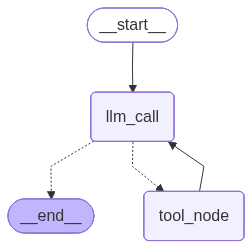

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

[{'id': 'toolu_01XyC8fG49xBN6D9eN6QSFK9', 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01XyC8fG49xBN6D9eN6QSFK9)
 Call ID: toolu_01XyC8fG49xBN6D9eN6QSFK9
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is **7**.


In [23]:
# Step 1: Define tools and model

from langchain.tools import tool
from langchain.chat_models import init_chat_model


# model = init_chat_model(
#     "claude-sonnet-4-5-20250929",
#     temperature=0
# )

model = ChatAnthropic(model="claude-sonnet-4-5-20250929", api_key=config['ANTHROPIC_API_KEY'],temperature=0.0)

# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    inputs: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "inputs": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["inputs"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["inputs"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"inputs": result}

# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["inputs"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"inputs": messages})
for m in messages["inputs"]:
    m.pretty_print()

In [ ]:


agent = createAgent({
  model,
  tools: [searchDatabase],
  // Optional system prompt
  systemPrompt: "You are a helpful analyst. Use tools if needed, then provide analysis.",
  // Structured output - uses provider/tool strategy automatically
  responseFormat: AnalysisResult,
});

// Invoke - returns { messages, structuredResponse }
const result = await agent.invoke({
  messages: [{ role: "user", content: "Analyze sales trends for Q3, limit to top 5" }],
});

In [6]:
response = {'Supervisor': {'response': "The DFT_Agent is a powerful computational chemistry agent that can perform various Density Functional Theory (DFT) calculations. Here are the main capabilities:\n\n## Core Capabilities:\n\n1. **Structure Operations:**\n   - Build and manipulate atomic structures (slabs, molecules, adsorbates)\n   - Relax/optimize structures to find minimum energy configurations\n   - Create surface slabs with different Miller indices\n   - Add adsorbates to surfaces at specific sites\n\n2. **DFT Calculations:**\n   - Single-point energy calculations\n   - Structure relaxation/optimization\n   - Electronic structure calculations\n   - Support for various exchange-correlation functionals (PBE, BEEF-vdW, RPBE, etc.)\n   - Pseudopotential selection and management\n\n3. **Convergence Testing:**\n   - K-point convergence tests\n   - Energy cutoff convergence tests\n   - Vacuum layer convergence tests (for slabs)\n   - Slab thickness convergence tests\n\n4. **Advanced Analysis:**\n   - **Ensemble calculations** with BEEF-vdW functional for uncertainty quantification\n   - Adsorption energy calculations\n   - Energy distribution analysis\n   - Density of states (DOS) calculations\n   - Band structure calculations\n\n5. **Input/Output Management:**\n   - Generate input files for DFT codes (primarily GPAW)\n   - Parse and analyze calculation results\n   - Extract energies, forces, and other properties\n\n## Typical Workflows:\n\n- **Adsorption Energy Studies:** Calculate energies of clean slab, adsorbate, and slab+adsorbate system to determine adsorption energies\n- **Uncertainty Quantification:** Use BEEF-vdW ensemble calculations to get error bars on energies\n- **Surface Science:** Study catalytic reactions, surface reconstructions, and adsorbate configurations\n\n## Important Notes:\n- For adsorption energy calculations, all systems (clean slab, adsorbate, slab+adsorbate) must use the **same functional**\n- For ensemble calculations with BEEF-vdW, you need to first relax structures, then run ensemble calculations with the relaxed geometry\n- The agent can handle convergence testing but typically only for the most complex system to save computational resources\n\nIs there a specific DFT calculation or analysis you'd like help with?", 'next': 'FINISH'}}


print(response['Supervisor']['response'])

The DFT_Agent is a powerful computational chemistry agent that can perform various Density Functional Theory (DFT) calculations. Here are the main capabilities:

## Core Capabilities:

1. **Structure Operations:**
   - Build and manipulate atomic structures (slabs, molecules, adsorbates)
   - Relax/optimize structures to find minimum energy configurations
   - Create surface slabs with different Miller indices
   - Add adsorbates to surfaces at specific sites

2. **DFT Calculations:**
   - Single-point energy calculations
   - Structure relaxation/optimization
   - Electronic structure calculations
   - Support for various exchange-correlation functionals (PBE, BEEF-vdW, RPBE, etc.)
   - Pseudopotential selection and management

3. **Convergence Testing:**
   - K-point convergence tests
   - Energy cutoff convergence tests
   - Vacuum layer convergence tests (for slabs)
   - Slab thickness convergence tests

4. **Advanced Analysis:**
   - **Ensemble calculations** with BEEF-vdW functio

In [34]:
from ursa.agents import ArxivAgent

In [35]:
from langchain_anthropic import ChatAnthropic

In [36]:
from pathlib import Path
ursaWorkspace = Path("/nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent/ursa_workspace_test")
agent = ArxivAgent(llm=llm, process_images=False, max_results=2, workspace=ursaWorkspace)

In [37]:
result = await agent.ainvoke(
    arxiv_search_query="oxygen evolution reaction catalyst", 
    context="What is the best catalyst for oxygen evolution reaction?"
)

In [38]:
print(result["final_summary"])

# Best Catalysts for Oxygen Evolution Reaction (OER)

Based on the provided summaries, I can offer insights about promising OER catalysts, though the information is limited to make a definitive "best catalyst" determination.

## Key Insights:

1. **Iron-doped copper oxide (CuO)** shows excellent promise:
   - The CF1 sample (1.56% Fe doping) demonstrates low overpotential (338 mV at 10 mA cm⁻²)
   - Small Tafel slope (69 mV dec⁻¹)
   - Good stability (>10 hours at 10+ mA cm⁻²)
   - Additional benefit of wastewater remediation capabilities

2. **Catalyst design principles** that appear important:
   - **Spin considerations**: Catalysts that facilitate the spin transition from singlet reactants to triplet O₂ product
   - **Materials with half-metallic conductivity** that can transport spin-polarized electrons
   - Catalysts with optimized:
     - Crystal field splitting
     - Coordination environment
     - Oxidation states
     - eg electron occupation
     - Electrical conductivity
  

In [13]:
print(result["final_summary"])

# Best Catalysts for Oxygen Evolution Reaction (OER)

Based on the provided summaries, I can offer insights about the best catalysts for oxygen evolution reaction:

## Noble Metal-Based Catalysts
- **Iridium-based catalysts** appear to be among the best in terms of stability, as mentioned in summary [1]
- However, these contain critical (rare and expensive) materials, making them less sustainable for large-scale applications

## Earth-Abundant Alternatives
- **Iron-doped copper oxide (CuO)** shows promising performance as highlighted in summary [2]:
  - Achieves low overpotential (338 mV at 10 mA cm⁻²)
  - Small Tafel slope (69 mV dec⁻¹)
  - Maintains stability for over 10 hours
  - Uses a straightforward sol-gel synthesis method
  - Offers cost advantages as a non-noble metal catalyst

- Other earth-abundant alternatives mentioned in summary [1] include:
  - Manganese oxides (Mn-based)
  - Cobalt oxides (Co-based)
  - Nickel oxides (Ni-based)

## Important Considerations
The "best" ca

In [4]:
from GNoME_aqueous_stability.src.gnome_aqueous_stability.data_utils import Data_Handler
from GNoME_aqueous_stability.src.gnome_aqueous_stability.analysis_utils import (
    plot_periodic_table_with_values, get_col_dict_for_atoms, 
    Stable_Entries, Stability_Criteria, get_simplified_df, 
    atoms_from_db
)

In [5]:
dir_of_data = None
solid_filter = True
gga_only = True
elements_to_exclude = []
elements_whic_must_be_included = []
pHs = 0.0
Us = [1.2, 2.0]
decomposition_threshold = 0.5
filters = []

In [6]:
dh = Data_Handler(
# Whether to apply solid filter:
    solid_filter = solid_filter, 
# Whether to use only GGA calculations (True), or include r2SCAN data via the MP-mixing scheme (False):
    gga_only = gga_only,
# Path to data directory:
    path_to_data_directory = "/nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent/GNoME_aqueous_stability/data"
    )

if len(elements_to_exclude) > 0:
    dh.remove_entries_with_elements(elements_to_exclude)
if len(elements_whic_must_be_included) > 0:
    dh.remove_entries_without_elements(elements_whic_must_be_included, True)

SCS = [Stability_Criteria(pHs=pHs, Us=Us, decomposition_threshold=decomposition_threshold),
    # Stability_Criteria(pHs=0, Us=[1.2, 1.6], decomposition_threshold=0.05),
    # Stability_Criteria(pHs=[2, 5], Us=[0., 2], decomposition_threshold=1),
    ]

se = Stable_Entries(dh, SCS)
df = se.get_stable_df()

Only GGA/GGA(+U) results will be used for stability analysis.


100%|█████████████████████████████████| 528971/528971 [01:20<00:00, 6595.11it/s]


Found 28765 stable entries given the stability criteria.


In [7]:
df.columns


Index(['Composition', 'MaterialId', 'Reduced Formula', 'Elements', 'NSites',
       'Volume', 'Density', 'Point Group', 'Space Group', 'Space Group Number',
       'Crystal System', 'Uncorrected Energy', 'Corrected Energy',
       'Formation Energy Per Atom', 'Decomposition Energy Per Atom',
       'Dimensionality Cheon', 'Bandgap', 'Is Train',
       'Decomposition Energy Per Atom All',
       'Decomposition Energy Per Atom Relative',
       'Decomposition Energy Per Atom MP',
       'Decomposition Energy Per Atom MP OQMD', 'Data Directory',
       'gga_only_pbx_save_id', 'mixed_pbx_save_id', 'Disorder Probability',
       'HHI_P_excluding_OHCNP', 'HHI_P_average', 'HHI_P_max'],
      dtype='object')

In [22]:
def apply_filter_strings_eval(df, filters):
    out = df
    for expr in filters:
        mask = out.eval(expr, engine="python")
        print(mask)
        if mask.dtype != bool:
            raise ValueError(f"Filter did not produce a boolean mask: {expr}")
            # return f"Filter did not produce a boolean mask: {expr}"
        out = out.loc[mask]
    return out

In [46]:
filters = ["`Elements`.values.tolist().count('Ir')"]

newDf = apply_filter_strings_eval(df, filters)

hh
0


AttributeError: 'int' object has no attribute 'dtype'

In [48]:
df['Elements'].values.tolist()

[['O', 'Mo', 'Dy', 'Ho'],
 ['F', 'Y', 'Zr', 'Nd'],
 ['B', 'O', 'Ba', 'Tl'],
 ['F', 'Tb', 'Pb', 'Bi'],
 ['O', 'Y', 'Tm', 'Lu', 'W'],
 ['O', 'F', 'P', 'K', 'Cr', 'Ga'],
 ['O', 'Tb', 'Dy', 'W'],
 ['O', 'F', 'P', 'K', 'Mn', 'Fe'],
 ['O', 'Sr', 'Ag', 'Pt'],
 ['O', 'Sb', 'Sm', 'Dy', 'Ho'],
 ['F', 'Ge', 'Y', 'Dy', 'Pt'],
 ['O', 'Gd', 'Dy', 'Tm', 'Ta'],
 ['F', 'Y', 'Eu', 'Ho'],
 ['O', 'Mn', 'Fe', 'Ba'],
 ['O', 'Cd', 'I', 'Nd'],
 ['O', 'Bi', 'Pu'],
 ['O', 'Ti', 'Pr', 'Nd'],
 ['O', 'Se', 'Mo', 'La', 'Nd'],
 ['O', 'Si', 'Ga', 'Ge', 'Ba'],
 ['F', 'Ti', 'Gd'],
 ['O', 'Sr', 'Cd', 'Sb', 'Ta'],
 ['O', 'Ti', 'Sr', 'Ba', 'La'],
 ['F', 'Cu', 'Y', 'Ba'],
 ['O', 'Sr', 'Ir', 'Bi'],
 ['O', 'K', 'W'],
 ['F', 'K', 'Sc', 'As'],
 ['Li', 'O', 'Si', 'Y', 'Er'],
 ['O', 'Tb', 'Bi'],
 ['O', 'P', 'V', 'Nb'],
 ['O', 'S', 'Sn', 'Tl'],
 ['O', 'Se', 'Nd', 'Gd', 'Er'],
 ['O', 'Eu', 'Pb'],
 ['O', 'Rh', 'Er', 'Ir', 'Bi'],
 ['Li', 'O', 'La', 'Tb', 'W'],
 ['B', 'O', 'Ni', 'Ho', 'Tm'],
 ['O', 'Pr', 'Pt', 'Th'],
 ['O', 'Y', 'Nb'

In [1]:
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple, Union

import pandas as pd

In [2]:
@dataclass(frozen=True)
class Relation:
    name: str                    # attribute name on parent row, e.g. "progress"
    child_table: str             # table name registered in RelationalFrame
    fk_in_child: str             # foreign key column in child, e.g. "experiment_ID"
    parent_pk: str               # parent primary key column, e.g. "experiment_ID"
    cardinality: str             # "one_to_one" or "one_to_many"
    local_key_in_child: Optional[str] = None  # optional "local id" for indexing inside the related view (e.g. "step")

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Union

import pandas as pd


@dataclass(frozen=True)
class Relation:
    name: str
    child_table: str
    fk_in_child: str
    parent_pk: str
    # cardinality: str  # "one_to_one" or "one_to_many"
    local_key_in_child: Optional[str] = None


class RowView:
    """
    Single-row view.
      - row.col -> scalar
      - row.<relation> -> RelatedView
      - row.df -> 1-row DataFrame
    """
    def __init__(self, table: "Table", pk_value: Any):
        self._table = table
        self._pk_value = pk_value

    @property
    def table(self) -> "Table":
        return self._table

    @property
    def pk(self) -> Any:
        return self._pk_value

    @property
    def series(self) -> pd.Series:
        return self._table._get_row_series(self._pk_value)

    @property
    def df(self) -> pd.DataFrame:
        hits = self._table.df.loc[self._table.df[self._table.pk] == self._pk_value]
        if len(hits) != 1:
            raise KeyError(
                f"Table '{self._table.name}' expected 1 row where {self._table.pk}=={self._pk_value!r}, got {len(hits)}"
            )
        return hits.copy()

    def __getattr__(self, name: str) -> Any:
        if name in self._table.df.columns:
            return self.series[name]

        rel = self._table.relations.get(name)
        if rel is not None:
            return RelatedView(parent_row=self, relation=rel)

        raise AttributeError(f"{self.__class__.__name__} has no attribute '{name}'")
    
    def __setattr__(self, name: str, value: Any) -> None:
        # internal attributes must still work normally
        if name.startswith("_"):
            object.__setattr__(self, name, value)
            return

        # if it's a real column name, write-through to the backing DataFrame
        if name in self._table.df.columns:
            self._table.set_value(self._pk_value, name, value)
            return

        # prevent accidentally overwriting relations or random attributes
        if name in self._table.relations:
            raise AttributeError(f"'{name}' is a relation; assign via child table inserts/updates instead")

        raise AttributeError(f"Unknown attribute/column '{name}' on {self}")

    def __repr__(self) -> str:
        return f"<RowView {self._table.name}[{self._pk_value!r}]>"


class RelatedView:
    """
    Filtered child-table view for a specific parent row.
      - .df gives filtered DataFrame
      - [key] selects one child row (by local key if provided; else by child pk)
      - add_row(...) inserts into child and auto-fills FK
      - groupby / merge wrappers operate on .df
    """
    def __init__(self, parent_row: RowView, relation: Relation):
        self._parent_row = parent_row
        self._relation = relation

    @property
    def parent_relation(self) -> Relation:
        return self._relation
    
    @property
    def relations(self) -> Dict[str, Relation]:
        return self.child_table.relations

    @property
    def child_table(self) -> "Table":
        rf = self._parent_row.table.rf
        return rf.table(self._relation.child_table)

    @property
    def df(self) -> pd.DataFrame:
        parent_pk_val = self._parent_row.pk
        child = self.child_table
        return child.df.loc[child.df[self._relation.fk_in_child] == parent_pk_val]

    # wrappers
    def groupby(self, *args, **kwargs):
        return self.df.groupby(*args, **kwargs)

    def merge(self, other: Union["Table", "RelatedView", pd.DataFrame], *args, **kwargs) -> pd.DataFrame:
        other_df = other.df if hasattr(other, "df") else other
        return self.df.merge(other_df, *args, **kwargs)

    # inserts (auto-fill FK)
    def add_row(
        self,
        row: Optional[Dict[str, Any]] = None,
        *,
        allow_update: bool = False,
        allow_new_columns: bool = False,
        **kwargs,
    ) -> RowView:
        data = {}
        if row:
            data.update(row)
        data.update(kwargs)

        # auto set FK -> parent pk value
        data[self._relation.fk_in_child] = self._parent_row.pk

        # delegate to child table
        return self.child_table.add_row(
            data,
            allow_update=allow_update,
            allow_new_columns=allow_new_columns,
        )

    def add_rows(
        self,
        rows: List[Dict[str, Any]],
        *,
        allow_update: bool = False,
        allow_new_columns: bool = False,
    ) -> List[RowView]:
        out = []
        for r in rows:
            out.append(
                self.add_row(
                    r,
                    allow_update=allow_update,
                    allow_new_columns=allow_new_columns,
                )
            )
        return out

    # row selection
    def __getitem__(self, key: Any) -> RowView:
        child = self.child_table
        sub = self.df

        if self._relation.local_key_in_child:
            col = self._relation.local_key_in_child
            hits = sub.loc[sub[col] == key]
            if len(hits) != 1:
                raise KeyError(
                    f"Expected exactly 1 row in related '{self._relation.name}' where {col}=={key!r}, got {len(hits)}"
                )
            pk_val = hits.iloc[0][child.pk]
            return child[pk_val]

        return child[key]

    def __iter__(self):
        child = self.child_table
        for pk_val in self.df[child.pk].tolist():
            yield child[pk_val]

    def __len__(self) -> int:
        return len(self.df)

    def __repr__(self) -> str:
        return f"<RelatedView {self._parent_row} -> {self._relation.name} ({len(self)} rows)>"


class Table:
    """
    DataFrame wrapper with PK, relations, and pandas-like wrappers.
      - table[pk] -> RowView
      - table.df -> underlying DataFrame
      - table.add_row / add_rows inserts after creation
      - table.groupby / merge wrappers forward to pandas
    """
    def __init__(self, rf: "RelationalFrame", name: str, df: pd.DataFrame, pk: str):
        self.rf = rf
        self.name = name
        self.pk = pk
        self.relations: Dict[str, Relation] = {}

        if pk not in df.columns:
            raise ValueError(f"Table '{name}' pk='{pk}' not found in columns: {list(df.columns)}")
        if df[pk].isna().any():
            raise ValueError(f"Table '{name}' pk column '{pk}' contains NaN")
        if df[pk].duplicated().any():
            dups = df.loc[df[pk].duplicated(), pk].tolist()[:10]
            raise ValueError(f"Table '{name}' pk '{pk}' must be unique; duplicates like: {dups}")

        self.df = df.reset_index(drop=True).copy()

    # relationship
    def add_relation(
        self,
        name: str,
        child_table: str,
        fk_in_child: str,
        # cardinality: str,
        local_key_in_child: Optional[str] = None,
    ) -> "Table":
        # if cardinality not in {"one_to_one", "one_to_many"}:
        #     raise ValueError("cardinality must be 'one_to_one' or 'one_to_many'")
        if name in self.relations:
            raise ValueError(f"Relation '{name}' already exists on table '{self.name}'")
        if local_key_in_child is None:
            local_key_in_child = self.rf.table(child_table).pk

        self.relations[name] = Relation(
            name=name,
            child_table=child_table,
            fk_in_child=fk_in_child,
            parent_pk=self.pk,
            # cardinality=cardinality,
            local_key_in_child=local_key_in_child,
        )
        return self

    # lookups
    def _get_row_series(self, pk_value: Any) -> pd.Series:
        hits = self.df.loc[self.df[self.pk] == pk_value]
        if len(hits) != 1:
            raise KeyError(f"Table '{self.name}' expected 1 row where {self.pk}=={pk_value!r}, got {len(hits)}")
        return hits.iloc[0]

    def __getitem__(self, pk_value: Any) -> RowView:
        # ensures row exists
        _ = self._get_row_series(pk_value)
        return RowView(self, pk_value)
    
    def set_value(self, pk_value: Any, column: str, value: Any, *, allow_new_columns: bool = False) -> None:
        if column not in self.df.columns:
            if not allow_new_columns:
                raise AttributeError(f"Unknown column '{column}' on table '{self.name}'")
            self.df[column] = pd.NA

        mask = (self.df[self.pk] == pk_value)
        if not mask.any():
            raise KeyError(f"Table '{self.name}' has no row with {self.pk}={pk_value!r}")

        self.df.loc[mask, column] = value

    # inserts
    def add_row(
        self,
        row: Union[Dict[str, Any], pd.Series],
        *,
        allow_update: bool = False,
        allow_new_columns: bool = False,
    ) -> RowView:
        if isinstance(row, pd.Series):
            row = row.to_dict()
        row = dict(row)

        if self.pk not in row:
            raise ValueError(f"Missing primary key '{self.pk}' for table '{self.name}'")
        pk_val = row[self.pk]
        if pd.isna(pk_val):
            raise ValueError(f"Primary key '{self.pk}' cannot be NA for table '{self.name}'")

        exists_mask = (self.df[self.pk] == pk_val)
        exists = bool(exists_mask.any())

        # handle new columns
        incoming_cols = set(row.keys())
        existing_cols = set(self.df.columns)

        if not incoming_cols.issubset(existing_cols):
            if not allow_new_columns:
                extra = sorted(list(incoming_cols - existing_cols))
                raise ValueError(
                    f"Table '{self.name}' got unknown columns {extra}. "
                    f"Pass allow_new_columns=True to add them."
                )
            for c in sorted(incoming_cols - existing_cols):
                self.df[c] = pd.NA

        # align to current schema (fill missing with NA)
        aligned = {c: row.get(c, pd.NA) for c in self.df.columns}

        if exists:
            if not allow_update:
                raise ValueError(f"Table '{self.name}' already has pk={pk_val!r}. Use allow_update=True to update.")
            # update existing row in-place (only provided keys)
            for k, v in row.items():
                self.df.loc[exists_mask, k] = v
        else:
            self.df = pd.concat([self.df, pd.DataFrame([aligned])], ignore_index=True)

        return self[pk_val]

    def add_rows(
        self,
        rows: List[Union[Dict[str, Any], pd.Series]],
        *,
        allow_update: bool = False,
        allow_new_columns: bool = False,
    ) -> List[RowView]:
        out = []
        for r in rows:
            out.append(
                self.add_row(
                    r,
                    allow_update=allow_update,
                    allow_new_columns=allow_new_columns,
                )
            )
        return out

    def update_row(self, pk_value: Any, **updates) -> RowView:
        return self.add_row({self.pk: pk_value, **updates}, allow_update=True, allow_new_columns=False)

    # wrappers
    def groupby(self, *args, **kwargs):
        return self.df.groupby(*args, **kwargs)

    def merge(self, other: Union["Table", RelatedView, pd.DataFrame], *args, **kwargs) -> pd.DataFrame:
        other_df = other.df if hasattr(other, "df") else other
        return self.df.merge(other_df, *args, **kwargs)

    def sort_values(self, *args, **kwargs) -> pd.DataFrame:
        return self.df.sort_values(*args, **kwargs)

    def query(self, *args, **kwargs) -> pd.DataFrame:
        return self.df.query(*args, **kwargs)

    def __repr__(self) -> str:
        return f"<Table {self.name} rows={len(self.df)} pk={self.pk}>"


class RelationalFrame:
    """
    Holds one root table + any number of child tables.
    """
    def __init__(self, root: str):
        self.root = root
        self._tables: Dict[str, Table] = {}

    def add_table(self, name: str, df: pd.DataFrame, pk: str) -> Table:
        if name in self._tables:
            raise ValueError(f"Table '{name}' already exists")
        t = Table(self, name=name, df=df, pk=pk)
        self._tables[name] = t
        return t

    def table(self, name: str) -> Table:
        if name not in self._tables:
            raise KeyError(f"Unknown table '{name}'. Known: {list(self._tables.keys())}")
        return self._tables[name]

    def __getattr__(self, name: str) -> Table:
        if name in self._tables:
            return self._tables[name]
        raise AttributeError(f"{self.__class__.__name__} has no attribute '{name}'")

    def enforce_referential_integrity(self) -> None:
        """
        Optional sanity check you can call after inserts.
        Checks:
          - child FK values must exist in parent PK values
          - one_to_one requires FK uniqueness inside child table
        """
        for parent in self._tables.values():
            parent_pk_vals = set(parent.df[parent.pk].tolist())
            for rel in parent.relations.values():
                child = self.table(rel.child_table)

                # FK exists
                if rel.fk_in_child not in child.df.columns:
                    raise ValueError(
                        f"Relation '{parent.name}.{rel.name}' expects child column '{rel.fk_in_child}', "
                        f"but it does not exist in '{child.name}'."
                    )

                bad = child.df.loc[~child.df[rel.fk_in_child].isin(parent_pk_vals), rel.fk_in_child].unique().tolist()
                if bad:
                    raise ValueError(
                        f"Broken FK in relation '{parent.name}.{rel.name}': child '{child.name}.{rel.fk_in_child}' "
                        f"contains values not in parent '{parent.name}.{parent.pk}': {bad[:10]}"
                    )

                # if rel.cardinality == "one_to_one":
                #     if child.df[rel.fk_in_child].duplicated().any():
                #         dups = child.df.loc[child.df[rel.fk_in_child].duplicated(), rel.fk_in_child].tolist()[:10]
                #         raise ValueError(
                #             f"Relation '{parent.name}.{rel.name}' is one_to_one but child FK "
                #             f"'{child.name}.{rel.fk_in_child}' has duplicates like: {dups}"
                #         )
        
        print("Referential integrity check passed.")

    def flatten_explode(
        self,
        root: Optional[str] = None,
        drop_foreign_keys: bool = True,
    ) -> pd.DataFrame:
        """
        Recursively left-join all reachable relations starting from root.
        One-to-many relations naturally "explode" into multiple rows via merge.

        Column naming:
          - root columns: experiment.experiment_ID, experiment.note, ...
          - relation path: progress.step, progress.status, ...
          - deeper: progress.some_child.col, ...

        If you have multiple one-to-many branches at the same level, merges will create
        the cartesian product, which is the usual "explode one-to-many" behavior.
        """
        root_name = root or self.root
        root_table = self.table(root_name)
        df = self._flatten_table(table=root_table, path=root_name, visited=set())

        if drop_foreign_keys:
            # drop obvious FK columns that came from child sides when they match a parent join key,
            # but keep anything that's not clearly a join artifact.
            drop_cols = [c for c in df.columns if c.endswith(".") is False and False]  # no-op, kept simple
            _ = drop_cols  # placeholder (you can extend heuristics if you want)

        return df

    def _flatten_table(self, table: Table, path: str, visited: set) -> pd.DataFrame:
        # prevent cycles
        key = (table.name, path)
        if key in visited:
            return self._prefix_df(table.df, path)

        visited = set(visited)
        visited.add(key)

        base = self._prefix_df(table.df, path)

        # Merge each relation's flattened child into base
        for rel_name, rel in table.relations.items():
            child = self.table(rel.child_table)
            child_path = f"{rel_name}" if path == self.root else f"{path}.{rel_name}"

            child_flat = self._flatten_table(child, child_path, visited)

            left_on = f"{path}.{table.pk}"
            right_on = f"{child_path}.{rel.fk_in_child}"

            # one_to_one: still a merge; enforce uniqueness of fk in child if you want stricter checks
            base = base.merge(child_flat, how="left", left_on=left_on, right_on=right_on)

        return base

    @staticmethod
    def _prefix_df(df: pd.DataFrame, path: str) -> pd.DataFrame:
        out = df.copy()
        out.columns = [f"{path}.{c}" for c in out.columns]
        return out

    def __repr__(self) -> str:
        return f"<RelationalFrame root={self.root} tables={list(self._tables.keys())}>"



In [188]:
rf = RelationalFrame(root="experiment")

In [189]:
experiment_df = pd.DataFrame(
        [
            {"experiment_ID": 1, "reason_or_hypothesis": "xxx", "note": "note1"},
            {"experiment_ID": 2, "reason_or_hypothesis": "yyy", "note": "note2"},
        ]
    )

progress_df = pd.DataFrame(
        [
            {"progress_id": 101, "experiment_ID": 1, "step": 1, "status": "done", "note": "a"},
            {"progress_id": 102, "experiment_ID": 1, "step": 2, "status": "submitted", "note": "b"},
            {"progress_id": 201, "experiment_ID": 2, "step": 1, "status": "done", "note": "c"},
        ]
    )

progressResult_df = pd.DataFrame(
        [
            {"progress_result_id": 1001, "progress_id": 101, "metric": "accuracy", "value": 0.95},
            {"progress_result_id": 1002, "progress_id": 101, "metric": "loss", "value": 0.1},
            {"progress_result_id": 1003, "progress_id": 102, "metric": "accuracy", "value": 0.9},
            {"progress_result_id": 2001, "progress_id": 201, "metric": "accuracy", "value": 0.85},
        ]
    )

In [190]:
rf.add_table("experiment", experiment_df, pk="experiment_ID")

<Table experiment rows=2 pk=experiment_ID>

In [191]:
rf.experiment.df

,experiment_ID,reason_or_hypothesis,note
0,1,xxx,note1
1,2,yyy,note2


In [192]:
rf.add_table("progress", progress_df, pk="progress_id")

<Table progress rows=3 pk=progress_id>

In [193]:
rf.progress[102].df

,progress_id,experiment_ID,step,status,note
1,102,1,2,submitted,b


In [194]:
rf.add_table("progress_result", progressResult_df, pk="progress_result_id")

<Table progress_result rows=4 pk=progress_result_id>

In [195]:
# Declare relation: experiment -> progress (one-to-many)
# local_key_in_child="step" enables: rf.experiment[1].progress[2] means step==2 within that experiment
rf.experiment.add_relation(
    name="progress",
    child_table="progress",
    fk_in_child="experiment_ID",
)

<Table experiment rows=2 pk=experiment_ID>

In [196]:
rf.progress.add_relation(
    name="progress_result",
    child_table="progress_result",
    fk_in_child="progress_id",
)

<Table progress rows=3 pk=progress_id>

### Creat RelationalFrame -> Add PD Table -> Build Relations

**Table Selection**\
RelationalFrame.<table\>\
\
**View Table**\
RelationalFrame.<table\>.df\
\
**View Relations**\
RelationalFrame.<table\>.relations\
\
**Select Row**\
RelationalFrame.<table\>[primary_key\]\
\
**Select Value of Row**\
RelationalFrame.<table\>[primary_key\].<column\>\
\
**Select SubTable(s)**\
RelationalFrame.<table\>[primary_key\].<subTable(relation)\>\
\
**Add Row**\
RelationalFrame.<table\>.add_row(Dict/pd)\
RelationalFrame.<table\>[primary_key\].<subTable(relation)\>.add_row(Dict/pd)

In [204]:
ExpLog = RelationalFrame(root="candidates")

In [205]:
# creat an arbitrary class
class study_object:
    def __init__(self, id, name):
        self.id = id
        self.name = name

tmpStudyObj1 = study_object(1, "test_study1")
tmpStudyObj2 = study_object(2, "test_study2")

In [206]:
study_df = pd.DataFrame(columns=["candidate_id", "reason_or_hypothesis", "notes", "study_obj"])

In [207]:
ExpLog.add_table("candidates", study_df, pk="candidate_id")

<Table candidates rows=0 pk=candidate_id>

In [221]:
ExpLog.candidates.add_row(
    {"candidate_id": 1, "reason_or_hypothesis": "xxx", "notes": "note1", "study_obj": tmpStudyObj1},
    allow_update=True
)

<RowView candidates[1]>

In [228]:
process_df = pd.DataFrame(columns=["process_id", "candidate_id", "job_type", "slurmID", "status", "VASP_dir", "processNote"])

In [229]:
ExpLog.add_table("processes", process_df, pk="process_id")

<Table processes rows=0 pk=process_id>

In [231]:
ExpLog.candidates.add_relation(
    name="processes",
    child_table="processes",
    fk_in_child="candidate_id",
)

<Table candidates rows=1 pk=candidate_id>

In [234]:
ExpLog.candidates[1].processes.add_row(
    {"process_id": 101, "job_type": "bulk_relaxation", "slurmID": 12345, "status": "running", "VASP_dir": "/path/to/vasp1", "processNote": "bulk relaxation"},
)

<RowView processes[101]>

In [239]:
ExpLog.candidates[1].processes[101].VASP_dir

'/path/to/vasp1'

In [240]:
ExpLog.candidates[1].processes.add_row(
    {"process_id": 102, "job_type": "surface_relaxation", "slurmID": 12346, "status": "pending", "VASP_dir": "/path/to/vasp2", "processNote": "surface relaxation"},
)

<RowView processes[102]>

In [243]:
ExpLog.candidates.add_row(
    {"candidate_id": 2, "reason_or_hypothesis": "yyy", "notes": "note2", "study_obj": tmpStudyObj2}
)

<RowView candidates[2]>

In [244]:
ExpLog.flatten_explode()

,candidates.candidate_id,candidates.reason_or_hypothesis,candidates.notes,candidates.study_obj,processes.process_id,processes.candidate_id,processes.job_type,processes.slurmID,processes.status,processes.VASP_dir,processes.processNote
0,1,xxx,note1,<__main__.study_object object at 0x14f57145db50>,101,1,bulk_relaxation,12345,running,/path/to/vasp1,bulk relaxation
1,1,xxx,note1,<__main__.study_object object at 0x14f57145db50>,102,1,surface_relaxation,12346,pending,/path/to/vasp2,surface relaxation
2,2,yyy,note2,<__main__.study_object object at 0x14f57163e250>,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pickle
from mace.calculators import MACECalculator, mace_mp

with open("/nfs/turbo/coe-venkvis/ziqiw-turbo/material_agent/OER_MACE4/canvas.pickle", "rb") as f:
    canvas = pickle.load(f)

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [15]:
canvas["f429480021_10-1_termination0_OER_catalyst_study_surface_study_resultdf"]

,site type,add site element,position,G_approx(O),G(O),G_approx(OH),G(OH),G_approx(OOH),G(OOH)
0,on-top,K,"[5.209091803450115, 5.334161364297422, 22.8181...",2.672853,None,None,None,None,None
1,on-top,K,"[4.997997856230968, 1.3849456550201076, 21.721...",3.652864,None,None,None,None,None
2,on-top,Dy,"[1.959279244928894, -0.5967799885475503, 21.52...",3.234438,None,None,None,None,None
3,on-top,Ir,"[2.0887785069074964, 3.5405220652462526, 22.19...",1.641359,None,None,None,None,None
